In [ ]:
import sys, os,glob
from datetime import datetime, timedelta
from pathlib import Path
from time import time, sleep
from scipy.interpolate import RegularGridInterpolator, LinearNDInterpolator,interp1d
from scipy.spatial import cKDTree
from scipy import signal
import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os, sys, shutil
from datetime import datetime, timedelta
import pickle
import seawater

# NOTES to future users

This is a notebook which compares the speed of generating different interpolation schemes. The most accurate method uses a linear scattered interpolation to put child points into a parent index coordinate system. Then regular grid interpolation is used. The speed is dramatically improved if instead of vertical linear interpolation the S differences are assumed small. Probably fine for boundary coords.

The notebook has a bunch of functions and then runs through the steps (make list of L1, then extrap neighbors, then interpolate)

The function that is different from other levels is get_interpolated_z_fast, although it is not commented hugely


In [2]:
def get_L1_short_list(h_out_dir):
    '''generates a shortlist that has just LV1 nc files'''
    hnc_short_list = sorted([item.name for item in h_out_dir.iterdir()
        if (item.name[0:9]=='ocean_his' and item.name[-3:]=='.nc')])
    return hnc_short_list

In [5]:
def time_filter_L1(in_dir, h_list, out_dir,int_start):
    """
    Filter the files using a block window
    """
    print('-Filtering in time')
    vl = ['zeta', 'u', 'v', 'temp', 'salt', 'ubar','vbar']
    nh = len(h_list)   
    # test for gaps in h_list
    no_gaps = True
    dtg0 = int(int_start)
    for hh in h_list[1:]:
        dtsg = hh.strip().strip('.nc')[-4:]
        dtg1 = int(dtsg)
        if (dtg1-dtg0) > 1: #1 hour
            no_gaps = False
            print('** HAS GAPS **')
            break
        else:
            dtg0 = dtg1    
    # no hanning window using block average
    fac_list_H = (np.ones(24)*24)
   
    #no filtering
    nfilt = len(fac_list_H)
    #nd_f = Ldir['forecast_days']
    if no_gaps:
        print('--computing daily average')
        fac_list = fac_list_H
        for nt in range(0,nh-12,24): # This is what subsamples it down
            #loop through timestamps
            n_center = nt + 11 #center on noon
            aa = dict()
            for n in range(nfilt):
                #loop through files in hanning
                nn = n + nt #
                fn = in_dir / h_list[nn]
                #a = pickle.load(open(fn, 'rb'))
                a = xr.load_dataset(fn)
                for v in vl:
                    if n == 0:
                        aa[v] = a[v].values/fac_list[n]
                    else:
                        aa[v] = aa[v] + a[v].values/fac_list[n]
            ds = nc.Dataset(in_dir / h_list[n_center])
            th = ds['ocean_time'][0]
            tu = ds['ocean_time'].units
            # e.g. 'seconds since 1999-01-01 12:00:00'
            # Warning: Brittle code below!
            ymd = tu.split()[2]
            hmss = tu.split()[3]
            hms = hmss.split('.')[0]
            roms_dt0 = datetime.strptime(ymd + ' ' + hms, '%Y-%m-%d %H:%M:%S')
            this_dt = roms_dt0 + timedelta(days=(th/(24*3600)))

            out_name= 'fh'+datetime.strftime(this_dt,"%Y.%m.%d")+'.p'
            aa['dt'] =this_dt
            print(' ' +out_name)
            pickle.dump(aa, open(out_dir / out_name, 'wb'))
    else:
        print('--Using block average (NOT TESTED FOR PFM')
        # make a simple average and use it for everything
        fac_list = list(nh * np.ones(nh))
        print(fac_list)
        aa = dict()
        for n in range(nh):
            fn = in_dir / h_list[n]
            a = pickle.load(open(fn, 'rb'))
            for v in vl:
                if n == 0:
                    aa[v] = a[v]/fac_list[n]
                else:
                    aa[v] = aa[v] + a[v]/fac_list[n]        
        if rtp == 'backfill':
            nd = 1
        else:
            nd = 3
        # saving the first file
        out_name0 = 'fh' + dts0 + '.p' 
        aa['dt'] = dt0
        # print('   ' + out_name0)
        pickle.dump(aa, open(out_dir / out_name0, 'wb'))
        # saving the last file
        dt1 = dt0 + timedelta(days=nd)
        dts1 = datetime.strftime(dt1, ds_fmt2)
        out_name1 = 'fh' + dts1 + '.p'            
        aa['dt'] = dt1           
        # print('   ' + out_name1)
        pickle.dump(aa, open(out_dir / out_name1, 'wb'))
  

In [4]:
def earth_rad(lat_deg):
    """
    Calculate the Earth radius (m) at a latitude
    (from http://en.wikipedia.org/wiki/Earth_radius) for oblate spheroid

    INPUT: latitude in degrees

    OUTPUT: Earth radius (m) at that latitute
    """
    a = 6378.137 * 1000; # equatorial radius (m)
    b = 6356.7523 * 1000; # polar radius (m)
    cl = np.cos(np.pi*lat_deg/180)
    sl = np.sin(np.pi*lat_deg/180)
    RE = np.sqrt(((a*a*cl)**2 + (b*b*sl)**2) / ((a*cl)**2 + (b*sl)**2))
    return RE

def ll2xy(lon, lat, lon0, lat0):
    """
    This converts lon, lat into meters relative to lon0, lat0.
    It should work for lon, lat scalars or arrays.
    NOTE: lat and lon are in degrees!!
    """
    R = earth_rad(lat0)
    clat = np.cos(np.pi*lat0/180)
    x = R * clat * np.pi * (lon - lon0) / 180
    y = R * np.pi * (lat - lat0) / 180
    return x, y

def get_coords(in_dir):
    """
    get coordinate fields and sizes
    """
    coord_dict = pickle.load(open(in_dir / 'coord_dict.p', 'rb'))
    Lon = coord_dict['lon_rho']
    Lat = coord_dict['lat_rho']
    s = coord_dict['s_rho']
    [M,L] =Lat.shape
    N = len(s)
    # Create arrays of distance from the center (m) so that the
    # nearest neighbor extrapolation is based on physical distance
    X, Y = ll2xy(Lon, Lat, Lon.mean(), Lat.mean())
    return (Lon, Lat, s, L, M, N, X, Y)

In [6]:
#extrap functions
def checknan(fld):
    """
    A utility function that issues a working if there are nans in fld.
    """
    if np.isnan(fld).sum() > 0:
        print('WARNING: nans in data field')  
        
def extrap_nearest_to_masked(X, Y, fld, fld0=0):
    """
    INPUT: fld is a 2D array (np.ndarray or np.ma.MaskedArray) on spatial grid X, Y
    OUTPUT: a numpy array of the same size with no mask
    and no missing values.        
    If input is a masked array:        
        * If it is ALL masked then return an array filled with fld0.         
        * If it is PARTLY masked use nearest neighbor interpolation to
        fill missing values, and then return data.        
        * If it is all unmasked then return the data.    
    If input is not a masked array:        
        * Return the array.    
    """
    # first make sure nans are masked
    [r,c] = fld.shape
    X = X.values.flatten()
    Y = Y.values.flatten()
    fld = fld.flatten()
    if np.ma.is_masked(fld) == False:
        fld = np.ma.masked_where(np.isnan(fld), fld)  
    if fld.all() is np.ma.masked:
        #print('  filling with ' + str(fld0))
        fldf = fld0 * np.ones(fld.data.shape)
        fldd = fldf.data
        checknan(fldd)
        return fldd
    elif ~fld.mask.any():
        fldd = fld.reshape((r,c))
        return fldd
        
    else:
        # do the extrapolation using nearest neighbor
        fldf = fld.copy() # initialize the "filled" field
        xyorig = np.array((X[~fld.mask],Y[~fld.mask])).T
        xynew = np.array((X[fld.mask],Y[fld.mask])).T
        a = cKDTree(xyorig).query(xynew)
        aa = a[1]
        fldf[fld.mask] = fld[~fld.mask][aa]
        fldd = fldf.data
        fldd = fldd.reshape((r,c))
        checknan(fldd)
        return fldd


def get_extrapolated(in_fn, L, M, N, X, Y, lon, lat, z, add_CTD=False):
    """
    Make use of extrap_nearest_to_masked() to fill fields completely
    before interpolating to the ROMS grid.  It also adds CTD data if asked to,
    creates ubar and vbar, and converts the temperature to potential temperature. Modified with Matt code to interpolate
    """
    b = pickle.load(open(in_fn, 'rb'))
    vn_list = list(b.keys())    
    # check that things are the expected shape
    def check_coords(shape_tuple, arr_shape,vn):
        if arr_shape != shape_tuple:
            print('WARNING: array shape mismatch')
            print(vn)
            print(arr_shape,shape_tuple)
    for vn in vn_list:
        if vn == 'dt':
            pass
        elif vn == 'zeta':
            b[vn] = b[vn].squeeze()
            check_coords((M, L), b[vn].shape,vn)
        elif vn == 'ubar':
            b[vn] = b[vn].squeeze()
            check_coords((M, L-1), b[vn].shape,vn)
        elif vn == 'u':
            b[vn] = b[vn].squeeze()
            check_coords((N, M, L-1), b[vn].shape,vn)
        elif vn == 'vbar':
            b[vn] = b[vn].squeeze()
            check_coords((M-1, L), b[vn].shape,vn)
        elif vn == 'v':
            b[vn] = b[vn].squeeze()
            check_coords((N,M-1, L), b[vn].shape,vn)
        else:
            b[vn] = b[vn].squeeze()
            check_coords((N, M, L), b[vn].shape,vn)    
    # creat output array and add dt to it.
    vn_list.remove('dt')
    V = dict()
    for vn in vn_list:
        V[vn] = np.nan + np.ones(b[vn].shape)
    V['dt'] = b['dt']    
    # extrapolate ssh
    vn = 'zeta'
    v = b[vn]
    #instead use nearest
    vv = extrap_nearest_to_masked(X, Y, v)
    V[vn] = vv
    vn_list.remove('zeta')    
    # extrapolate 3D fields
    for vn in vn_list:
        v = b[vn]
        if vn == 'temp':
            v0 = np.nanmin(v)
        elif vn == 'salt':
            v0 = np.nanmax(v)
        if vn in ['temp', 'salt']:
            # print(' -- extrapolating ' + vn)
            if add_CTD==False:
                for k in range(N):
                    fld = v[k, :, :]
                    fldf = extrap_nearest_to_masked(X, Y, fld, fld0=v0)
                    V[vn][k, :, :] = fldf
            elif add_CTD==True:
                continue
                '''
                print(vn + ' Adding CTD data before extrapolating')
                Cast_dict, sta_df = Ofun_CTD.get_casts(Ldir)
                for k in range(N):
                    fld = v[k, :, :]
                    zz = z[k]
                    xyorig, fldorig = Ofun_CTD.get_orig(Cast_dict, sta_df,
                        X, Y, fld, lon, lat, zz, vn)
                    fldf = Ofun_CTD.extrap_nearest_to_masked_CTD(X,Y,fld,
                        xyorig=xyorig,fldorig=fldorig,fld0=v0)
                    V[vn][k, :, :] = fldf
                '''
        elif vn in ['u', 'v','ubar','vbar']:
            # print(' -- extrapolating ' + vn)
            vv = v.copy()
            vv = np.ma.masked_where(np.isnan(vv), vv)
            vv[vv.mask] = 0
            V[vn] = vv
    
    ## borrowed code that is likely no longer necessary
    # Create ubar and vbar.
    # Note: this is slightly imperfect because the z levels are at the same
    # position as the velocity levels.
    #dz = np.nan * np.ones((N, 1, 1))
    #dz[1:, 0, 0]= np.diff(z)
    #dz[0, 0, 0] = dz[1, 0, 0]
    
    # account for the fact that the new hycom fields do not show up masked
    #u3d = np.ma.masked_where(np.isnan(b['u3d']),b['u3d'])
    #v3d = np.ma.masked_where(np.isnan(b['v3d']),b['v3d'])
    #dz3 = dz * np.ones_like(u3d) # make dz a masked array
    #b['ubar'] = np.sum(u3d*dz3, axis=0) / np.sum(dz3, axis=0)
    #b['vbar'] = np.sum(v3d*dz3, axis=0) / np.sum(dz3, axis=0)
    
    #for vn in ['ubar', 'vbar']:
        #v = b[vn]
        #vv = v.copy()
        #vv = np.ma.masked_where(np.isnan(vv), vv)
        #vv[vv.mask] = 0
        #V[vn] = vv.data  
    # calculate potential temperature
    #press_db = -z.reshape((N,1,1))
    #V['theta'] = seawater.ptmp(V['s3d'], V['t3d'], press_db)    
    return V

In [7]:
def get_basic_info(fn, only_G=False, only_S=False, only_T=False):
    """
    Gets grid, vertical coordinate, and time info from a ROMS NetCDF
    history file with full name 'fn'
    Input: the filename (with path if needed)
    Output: dicts G, S, and T
    Example calls:
    G, S, T = zfun.get_basic_info(fn)
    T = zfun.get_basic_info(fn, only_T=True)
    """
    ds = xr.open_dataset(fn)
    def make_G(ds):
        # get grid and bathymetry info
        g_varlist = ['h', 'lon_rho', 'lat_rho', 'lon_u', 'lat_u', 'lon_v', 'lat_v',
        'lon_psi', 'lat_psi', 'mask_rho', 'mask_u', 'mask_v', 'pm', 'pn', 'angle']
        G = dict()
        for vv in g_varlist:
            G[vv] = ds[vv].values
        G['DX'] = 1/G['pm']
        G['DY'] = 1/G['pn']
        G['M'], G['L'] = np.shape(G['lon_rho']) # M = rows, L = columns
        return G
    def make_S(ds):
        # get vertical sigma-coordinate info (vectors are bottom to top)
        s_varlist = ['s_rho', 's_w', 'hc', 'Cs_r', 'Cs_w', 'Vtransform']
        S = dict()
        for vv in s_varlist:
            S[vv] = ds[vv].values
        S['N'] = len(S['s_rho']) # number of vertical levels
        return S
    def make_T(ds):
        # returns two single values, one a datatime, and one a float
        ot = ds.ocean_time.values # an array with dtype='datetime64[ns]'
        dti = pd.to_datetime(ot) # a pandas DatetimeIndex with dtype='datetime64[ns]'
        dt = dti.to_pydatetime() # an array of datetimes
        T = dict()
        T['dt'] = dt[0] # a datetime object
        T['ocean_time'] = Lfun.datetime_to_modtime(dt[0]) # a float, "seconds since..."
        return T
    # return results
    if only_G:
        return make_G(ds)
    elif only_S:
        return make_S(ds)
    elif only_T:
        return make_T(ds)
    else:
        return make_G(ds), make_S(ds), make_T(ds)
    ds.close()


In [8]:
def get_S(S_info_dict):
    """
    Code to calculate S-coordinate vectors from the parameters
    in S_COORDINATE_INFO.csv.
    Need to check this carefully against the matlab version.
    # recoded for python on 7/7/2016 from:
    # Z_scoord.m  5/21/2007  Parker MacCready
    # this creates the structure S, which would be used for example by
    # Z_s2z.m, given basic grid parameters
    # edited by DAS to include more things in S stucture
    # edited by SNG March 2011 to include all of the current available ROMS
    # stretching functions, 1-4 see:
    # https://www.myroms.org/wiki/index.php/Vertical_S-coordinate#Vertical_Stretching_Functions
    
    NOTES 2019.09.11
    (1) I checked that Cs_r and _w made by this program are identical to those which are
    given in the ROMS history files.  They are.
    (2) I also made some inquiries on the ROMS forum to make sure that the parameter 'hc' is
    being done correctly.  The short answer is that yes it is.  With Vtransform = 2 (my
    new default) it is given by Tcline from the .in file.  In older runs with Vtransform = 1
    is it min(hmin, Tcline) and this REQUIRES that Tcline be less than hmin.  Since all those
    older runs used Tcline = 0 then hc = 0.
    
    """
    S = dict()
    for item in S_info_dict.keys():
        if item in ['N', 'VSTRETCHING', 'VTRANSFORM']:
            S[item.title()] = int(S_info_dict[item])
        elif item in ['TCLINE', 'THETA_S', 'THETA_B']:
            S[item.lower()] = float(S_info_dict[item])
        else:
            pass
    N = S['N']
    Vstretching = S['Vstretching']
    Vtransform = S['Vtransform']
    tcline = S['tcline']
    theta_s = S['theta_s']
    theta_b = S['theta_b']
    hmin = 3 # a placeholder, used only for Vtransform = 1.
    if Vtransform == 1:
        hc = min(hmin,tcline)
    elif Vtransform == 2:
        hc = tcline
    S['hc'] = hc
    s_rho = (np.linspace(-(N-1), 0, N) - 0.5)/N
    s_w = np.linspace(-N, 0, N+1)/N
    S['s_rho'] = s_rho
    S['s_w'] = s_w
    if Vstretching == 1:
        if theta_s != 0:
            cff1 = 1/np.sinh(theta_s)
            cff2 = 0.5/np.tanh(0.5*theta_s)
            Cs_r = ( (1-theta_b)*cff1*np.sinh(theta_s*s_rho)
                    + theta_b*( cff2*np.tanh(theta_s*(s_rho + 0.5)) - 0.5 ) )
            Cs_w = ( (1-theta_b)*cff1*np.sinh(theta_s*s_w)
                    + theta_b*( cff2*np.tanh(theta_s*(s_w + 0.5)) - 0.5 ) )
        else:
            Cs_r = s_rho
            Cs_w = s_w
    elif Vstretching == 2:
        alpha = 1
        beta = 1
        if theta_s!=0 and theta_b!=0:
            Csur = (1-np.cosh(theta_s*s_rho))/(np.cosh(theta_s)-1)
            Cbot = ((np.sinh(theta_b*(s_rho+1)))/(np.sinh(theta_b)))-1
            u = ((s_rho+1)**alpha)*(1+(alpha/beta)*(1-((s_rho+1)**beta)))
            Cs_r = u*Csur+(1-u)*Cbot
            Csur_w = (1-np.cosh(theta_s*s_w))/(np.cosh(theta_s)-1)
            Cbot_w = ((np.sinh(theta_b*(s_w+1)))/(np.sinh(theta_b)))-1
            u_w = ((s_w+1)**alpha)*(1+(alpha/beta)*(1-((s_w+1)**beta)))
            Cs_w = u_w*Csur_w+(1-u_w)*Cbot_w
        else:
            Cs_r = s_rho
            Cs_w = s_w
    elif Vstretching == 3:
        # Geyer function for high bbl resolution in shallow applications
        gamma = 3
        Csur = -(np.log(np.cosh(gamma*abs(s_rho)**theta_s)))/np.log(np.cosh(gamma))
        Cbot = ((np.log(np.cosh(gamma*(s_rho+1)**theta_b)))/np.log(np.cosh(gamma)))-1
        mu = 0.5*(1-np.tanh(gamma*(s_rho+0.5)))
        Cs_r = mu*Cbot+(1-mu)*Csur
        Csur_w = -(np.log(np.cosh(gamma*abs(s_w)**theta_s)))/np.log(np.cosh(gamma))
        Cbot_w = ((np.log(np.cosh(gamma*(s_w+1)**theta_b)))/np.log(np.cosh(gamma)))-1
        mu_w = 0.5*(1-np.tanh(gamma*(s_w+0.5)))
        Cs_w = mu_w*Cbot_w+(1-mu_w)*Csur_w
    elif Vstretching == 4:
        # newest ROMS default as of March 2011 (theta_s between 0 and 10,
        # theta_b between 0 and 4)
        if theta_s>0:
            Cs_r = (1-np.cosh(theta_s*s_rho))/(np.cosh(theta_s)-1)
            Cs_w = (1-np.cosh(theta_s*s_w))/(np.cosh(theta_s)-1)
        elif theta_s<=0:
            Cs_r = -(s_rho**2)
            Cs_w = -(s_w**2)
        if theta_b > 0:
            Cs_r = (np.exp(theta_b*Cs_r)-1)/(1-np.exp(-theta_b))
            Cs_w = (np.exp(theta_b*Cs_w)-1)/(1-np.exp(-theta_b))
    S['Cs_r'] = Cs_r
    S['Cs_w'] = Cs_w
    return S
    
def get_z(h, zeta, S, only_rho=False, only_w=False):
    """
    Used to calculate the z position of fields in a ROMS history file

    Input: arrays h (bathymetry depth) and zeta (sea surface height)
    which must be the same size, and dict S created by get_basic_info()

    Output: 3-D arrays of z_rho and z_w

    NOTE: one foible is that if you input arrays of h and zeta that are
    vectors of length VL, the output array (e.g. z_rho) will have size (N, VL)
    (i.e. it will never return an array with size (N, VL, 1), even if (VL, 1) was
    the input shape).  This is a result of the initial and final squeeze calls.
    """
    # input error checking
    if ( (not isinstance(h, np.ndarray))
        or (not isinstance(zeta, (np.ndarray, np.ma.core.MaskedArray))) ):
        print('WARNING from get_z(): Inputs must be numpy arrays')
    if not isinstance(S, dict):
        print('WARNING from get_z(): S must be a dict')
    # number of vertical levels
    N = S['N']
    # remove singleton dimensions
    h = h.squeeze()
    zeta = zeta.squeeze()
    # ensure that we have enough dimensions
    h = np.atleast_2d(h)
    zeta = np.atleast_2d(zeta)
    # check that the dimensions are the same
    if h.shape != zeta.shape:
        print('WARNING from get_z(): h and zeta must be the same shape')
    M, L = h.shape
    def make_z_rho(h, zeta, S, N, M, L):
        # rho
        # create some useful arrays
        csr = S['Cs_r']
        csrr = csr.reshape(N, 1, 1).copy()
        Cs_r = np.tile(csrr, [1, M, L])
        H_r = np.tile(h.reshape(1, M, L).copy(), [N, 1, 1])
        Zeta_r = np.tile(zeta.reshape(1, M, L).copy(), [N, 1, 1])
        if S['hc'] == 0: # if hc = 0 the transform is simpler (and faster)
            z_rho = H_r*Cs_r + Zeta_r + Zeta_r*Cs_r
        elif S['hc'] != 0: # need to calculate a few more useful arrays
            sr = S['s_rho'] # PM edit 2019.01.24
            srr = sr.reshape(N, 1, 1).copy()
            S_rho = np.tile(srr, [1, M, L])
            Hc_r = np.tile(S['hc'], [N, M, L])
            if S['Vtransform'] == 1:
                zr0 = (S_rho - Cs_r) * Hc_r + Cs_r*H_r
                z_rho = zr0 + Zeta_r * (1 + zr0/H_r)
            elif S['Vtransform'] == 2:
                zr0 = (S_rho*Hc_r + Cs_r*H_r) / (Hc_r + H_r)
                z_rho = Zeta_r + (Zeta_r + H_r)*zr0
        z_rho = z_rho.squeeze()
        return z_rho
    def make_z_w(h, zeta, S, N, M, L):
        # w
        # create some useful arrays
        csw = S['Cs_w']
        csww = csw.reshape(N+1, 1, 1).copy()
        Cs_w = np.tile(csww, [1, M, L])
        H_w = np.tile(h.reshape(1, M, L).copy(), [N+1, 1, 1])
        Zeta_w = np.tile(zeta.reshape(1, M, L).copy(), [N+1, 1, 1])
        if S['hc'] == 0: # if hc = 0 the transform is simpler (and faster)
            z_w = H_w*Cs_w + Zeta_w + Zeta_w*Cs_w
        elif S['hc'] != 0: # need to calculate a few more useful arrays
            #sw = S['s_w']
            sw = S['s_w'] # PM edit 2019.01.24
            sww = sw.reshape(N+1, 1, 1).copy()
            S_w = np.tile(sww, [1, M, L])    #
            Hc_w = np.tile(S['hc'], [N+1, M, L])
            if S['Vtransform'] == 1:
                zw0 = (S_w - Cs_w) * Hc_w + Cs_w*H_w
                z_w = zw0 + Zeta_w * (1 + zw0/H_w)
            elif S['Vtransform'] == 2:
                zw0 = (S_w*Hc_w  + Cs_w*H_w) / (Hc_w + H_w)
                z_w = Zeta_w + (Zeta_w + H_w)*zw0
        z_w = z_w.squeeze()
        return z_w
    # return results
    if only_rho:
        return make_z_rho(h, zeta, S, N, M, L)
    elif only_w:
        return make_z_w(h, zeta, S, N, M, L)
    else :
        return make_z_rho(h, zeta, S, N, M, L), make_z_w(h, zeta, S, N, M, L)


In [55]:
def shift_coords(angle, X_o,Y_o,X_new,Y_new):
    """
    IGNORE THIS FUNCTION. THERE IS A BETTER WAY. This code shifts the coords to make the data rectilinear. It takes angle which will be used to rotate the data
    and . 
    """
    dX = X_new-X_o
    dY = Y_new-Y_o
    X_rot = np.cos(angle) * dX + np.sin(angle) * dY
    Y_rot = np.cos(angle) * dY - np.sin(angle) * dX
    return X_rot, Y_rot

In [53]:
def get_interpolated_z(G_child, S_child, b, G_parent, S_parent, zr_parent, zr_child):
    """
    This does the horizontal and vertical interpolation to get from
    extrapolated, filtered HYCOM fields to ROMS fields.

    We use fast nearest neighbor interpolation as much as possible.
    Also we interpolate everything to the ROMS rho grid, and then crudely
    interpolate to the u and v grids at the last moment.  Much simpler.

    Modified by Bob S. to use linear interp
    
    """
    N_child = S_child['N']
    N_parent = S_parent['N']
    # start input dict
    c = {}
    clat = G_parent['lat_rho'].mean()
    clon = G_parent['lon_rho'].mean()

    #move everything into x and y
    X_parent, Y_parent = ll2xy(G_parent['lon_rho'], G_parent['lat_rho'], clon, clat)
    X_child, Y_child = ll2xy(G_child['lon_rho'], G_child['lat_rho'], clon, clat)
    X_u, Y_u = ll2xy(G_parent['lon_u'], G_parent['lat_u'], clon, clat)
    X_v, Y_v = ll2xy(G_parent['lon_v'], G_parent['lat_v'], clon, clat)

    #shift onto rectilinear grid
    angle_parent = G_parent['angle']
    angle_o = angle_parent.mean()
    X_o = X_parent[0,0]
    Y_o = Y_parent[0,0]
    nXp, nYp = shift_coords(angle_o,X_o,Y_o,X_parent,Y_parent)
    nXc, nYc = shift_coords(angle_o,X_o,Y_o,X_child,Y_child)
    nXu, nYu = shift_coords(angle_o,X_o,Y_o,X_u,Y_u)
    nXv, nYv = shift_coords(angle_o,X_o,Y_o,X_v,Y_v)
 
    #try rectilinear with LV2 indices

    #msk = gr.variables['mask_rho'][:,:]
    
    # precalculate useful arrays that are used for horizontal interpolation
    #if isinstance(Lon, np.ma.MaskedArray):
        #Lon = Lon.data
    #if isinstance(lat, np.ma.MaskedArray):
        #Lat = Lat.data
    #mf = 6 #fineness factor how much finer is the grid
    
    #loni = np.linspace(lon[0],lon[-1],mf*len(lon))
    #lati = np.linspace(lat[0],lat[-1],mf*len(lat))
    
    #Lnhi, Lthi = np.meshgrid(loni,lati, indexing='xy') #now we have a fine grid
    #old code
    #Lon, Lat = np.meshgrid(lon,lat)
    #XYin = np.array((Lon.flatten(), Lat.flatten())).T
    #XYr = np.array((G['lon_rho'].flatten(), G['lat_rho'].flatten())).T
    
    #XYin = np.array((Lnhi.flatten(), Lthi.flatten())).T
    #XYr = np.array((G['lon_rho'].flatten(), G['lat_rho'].flatten())).T
    # nearest neighbor interpolation from XYin to XYr is done below...
    h_child = G_child['h']
    angle_child = G_child['angle']
    #IMr = cKDTree(XYin).query(XYr)[1]  #old nearest neighbor
    #fix rotation
    #interp_Lxi = RegularGridInterpolator((nYu[:,0],nXu[0,:]), L1_xi,fill_value=0, bounds_error=False)

    interp_u = RegularGridInterpolator((nYu[:,0],nXu[0,:]), b['ubar'],fill_value=0, bounds_error=False)
    ubar_ip =interp_u((nYp,nXp))

    interp_v = RegularGridInterpolator((nYv[:,0],nXv[0,:]), b['vbar'],fill_value=0,bounds_error=False)
    vbar_ip =interp_v((nYp,nXp))
    u_nr = np.cos(-angle_parent) * ubar_ip + np.sin(-angle_parent) * vbar_ip #unrotate
    v_nr = np.cos(-angle_parent) * vbar_ip - np.sin(-angle_parent) * ubar_ip
    
    interp_func = RegularGridInterpolator((nYp[:,0],nXp[0,:]), b['zeta'])
    # 2D fields
    i = 0
    for vn in ['zeta', 'ubar','vbar']:
        if vn in ['ubar']:
            vi = u_nr
        elif vn in ['vbar']:
            vi = v_nr
        else:
            vi = b['zeta']
        # interp hycom to finer grid
        
        setattr(interp_func,'values',vi)
        vn_fi=interp_func((nYc,nXc))

        
        # interp to roms from the fine hycom ssh
        vv = vn_fi#.flatten()[IMr].reshape(h.shape)    
    
        vvc = vv.copy()
        # always a good idea to make sure dict entries are not just pointers
        # to arrays that might be changed later, hence the .copy()

        c[vn] = vvc
        checknan(vvc)
     #rotate velocites
    vu = c['ubar']
    vv = c['vbar']

    u = np.cos(angle_child) * vu + np.sin(angle_child) * vv
    v = np.cos(angle_child) * vv - np.sin(angle_child) * vu
    u = (u[:,:-1] + u[:,1:])/2
    v = (v[:-1,:] + v[1:,:])/2
    vvc = u.copy()
    c['ubar'] = vvc
    vvc = v.copy()
    c['vbar'] = vvc

     
    U_nr = np.zeros(((N_parent,) + X_parent.shape))
    V_nr = np.zeros(((N_parent,) + X_parent.shape))

    # unrotate the 3d velocities
    for nn in range(N_parent):
        #interp_u = RegularGridInterpolator((nYu,nXu), b['u'][nn,:,:],fill_value=0)
        setattr(interp_u,'values',b['u'][nn,:,:])
        ubar_ip =interp_u((nYp,nXp))
        setattr(interp_v,'values',b['v'][nn,:,:])
        vbar_ip =interp_v((nYp,nXp))
        u_nr = np.cos(-angle_parent) * ubar_ip + np.sin(-angle_parent) * vbar_ip #unrotate
        v_nr = np.cos(-angle_parent) * vbar_ip - np.sin(-angle_parent) * ubar_ip
        U_nr[nn,:,:] = u_nr
        V_nr[nn,:,:] = v_nr

        
        
    # 3D fields
    # First create intermediate array with parent lat and lon, but global z
    vv = np.nan*np.ones(((N_parent,)+X_parent.shape))
    vi_dict = {}
    # do the vertical interpolation from Parent to child z positions
    global_z = np.mean(zr_parent,axis=(1,2))
    for vn in [ 'salt', 'temp','u', 'v']:
        VV = vv.copy()
        if vn in ['u']:
            vi = U_nr
        elif vn in ['v']:
            vi = V_nr
        else:
            vi = b[vn]
        for k in range(G_parent['M']):
            for j in range(G_parent['L']):
                interp_z = interp1d(zr_parent[:,k,j], vi[:,k,j],  kind='linear', fill_value="extrapolate")  
                #hinds = np.indices((S['N'], G['M'], G['L']))
                #vvf = vi[zinds, hinds[1].flatten(), hinds[2].flatten()]
                #vv = vvf.reshape((S['N'], G['M'], G['L']))
                VV[:,k,j] = interp_z(global_z)

        checknan(VV)
        vi_dict[vn] = VV
    # create intermediate arrays which are on the child lon_rho, lat_rho grid

    F = np.nan * np.ones(((N_parent,) + h_child.shape))
    vi_dict2 = {}
    for vn in ['temp', 'salt', 'u', 'v']:
        FF = F.copy()
        for nn in range(N_parent):
            vin = vi_dict[vn][nn,:,:]
            # interp hycom to finer grid
            #interp_func = LinearNDInterpolator((Y_parent.flatten(),X_parent.flatten()), vin.flatten())
            setattr(interp_func,'values',vin)
            vn_fi=interp_func((nYc,nXc))
            #interp_func = RegularGridInterpolator((lat, lon), vin)
            #vn_fi=interp_func((Lthi,Lnhi))
            
            # interp to roms from the fine hycom ssh
            FF[nn,:,:] = vn_fi#.flatten()[IMr].reshape(h.shape)    
            #FF[nn,:,:] = vin[IMr].reshape(h.shape)
        checknan(FF)
        vi_dict2[vn] = FF
    
     


    vv2 = np.nan*np.ones(((N_child,)+h_child.shape))
    for vn in [ 'salt', 'temp','u', 'v']:
        VV2 = vv2.copy()
        vi = vi_dict2[vn]
        for k in range(G_child['M']):
            for j in range(G_child['L']):
                interp_z = interp1d(global_z, vi[:,k,j],  kind='linear', fill_value="extrapolate")  
                #hinds = np.indices((S['N'], G['M'], G['L']))
                #vvf = vi[zinds, hinds[1].flatten(), hinds[2].flatten()]
                #vv = vvf.reshape((S['N'], G['M'], G['L']))
                VV2[:,k,j] = interp_z(zr_child[:,k,j])

        checknan(VV2)
        c[vn] = VV2

        #hinds = np.indices((S['N'], G['M'], G['L']))
        #vvf = vi[zinds, hinds[1].flatten(), hinds[2].flatten()]
        #vv = vvf.reshape((S['N'], G['M'], G['L']))


     #rotate velocites
    vu = c['u']
    vv = c['v']
    u = np.nan * np.ones(((N_child,) + h_child.shape))
    v = np.nan * np.ones(((N_child,) + h_child.shape))
    for nn in range(N_child):
        u[nn,:,:] = np.cos(angle_child) * vu[nn,:,:] + np.sin(angle_child) * vv[nn,:,:]
        v[nn,:,:] = np.cos(angle_child) * vv[nn,:,:] - np.sin(angle_child) * vu[nn,:,:]
        
    u = (u[:,:,:-1] + u[:,:,1:])/2
    v = (v[:,:-1,:] + v[:,1:,:])/2
    vvc = u.copy()
    c['u'] = vvc
    vvc = v.copy()
    c['v'] = vvc

    return c

In [77]:
def get_interpolated_z_slow(G_child, S_child, b, G_parent, S_parent, zr_parent, zr_child):
    """
    This does the horizontal and vertical interpolation to get from
    extrapolated, filtered HYCOM fields to ROMS fields.

    We use fast nearest neighbor interpolation as much as possible.
    Also we interpolate everything to the ROMS rho grid, and then crudely
    interpolate to the u and v grids at the last moment.  Much simpler.

    Modified by Bob S. to use linear interp
    
    """
    N_child = S_child['N']
    N_parent = S_parent['N']
    # start input dict
    c = {}
    #playing with G and interpolation
    clat = G_parent['lat_rho'].mean()
    clon = G_parent['lon_rho'].mean()

    #move everything into x and y
    X_parent, Y_parent = ll2xy(G_parent['lon_rho'], G_parent['lat_rho'], clon, clat)
    X_child, Y_child = ll2xy(G_child['lon_rho'], G_child['lat_rho'], clon, clat)
    X_cu, Y_cu = ll2xy(G_child['lon_u'], G_child['lat_u'], clon, clat)
    X_cv, Y_cv = ll2xy(G_child['lon_v'], G_child['lat_v'], clon, clat)

    X_ind, Y_ind = np.meshgrid(np.arange(G_parent['L']),np.arange(G_parent['M']))


    parent_points = np.zeros((M*L,2))
    parent_points[:,1] = X_parent.flatten()
    parent_points[:,0] = Y_parent.flatten()


    xi_values = X_ind.flatten()
    scat_interp_xi = LinearNDInterpolator(parent_points,xi_values)

    eta_values = Y_ind.flatten()
    scat_interp_eta = LinearNDInterpolator(parent_points,eta_values)

    XI_child = scat_interp_xi(Y_child,X_child)
    ETA_child = scat_interp_eta(Y_child,X_child)

    #XIu_child = scat_interp_xi(Y_cu,X_cu)
    #ETAu_child = scat_interp_eta(Y_cu,X_cu)

    #XIv_child = scat_interp_xi(Y_cv,X_cv)
    #ETAv_child = scat_interp_eta(Y_cv,X_cv)

 

    h_child = G_child['h']
    angle_child = G_child['angle']
 

    interp_u = RegularGridInterpolator((np.arange(G_parent['M']),np.arange(G_parent['L']-1)), b['ubar'],fill_value=0, bounds_error=False)
    ubar_ip =interp_u((Y_ind,X_ind))

    interp_v = RegularGridInterpolator((np.arange(G_parent['M']-1),np.arange(G_parent['L'])), b['vbar'],fill_value=0,bounds_error=False)
    vbar_ip =interp_v((Y_ind,X_ind))

    u_nr = np.cos(-angle_parent) * ubar_ip + np.sin(-angle_parent) * vbar_ip #unrotate
    v_nr = np.cos(-angle_parent) * vbar_ip - np.sin(-angle_parent) * ubar_ip
    
    interp_func = RegularGridInterpolator((np.arange(G_parent['M']),np.arange(G_parent['L'])), b['zeta'])
    # 2D fields
    i = 0
    for vn in ['zeta', 'ubar','vbar']:
        if vn in ['ubar']:
            vi = u_nr
        elif vn in ['vbar']:
            vi = v_nr
        else:
            vi = b['zeta']
        # interp hycom to finer grid
        
        setattr(interp_func,'values',vi)
        vn_fi=interp_func((ETA_child,XI_child))

        
        # interp to roms from the fine hycom ssh
        vv = vn_fi#.flatten()[IMr].reshape(h.shape)    
    
        vvc = vv.copy()
        # always a good idea to make sure dict entries are not just pointers
        # to arrays that might be changed later, hence the .copy()

        c[vn] = vvc
        checknan(vvc)
     #rotate velocites
    vu = c['ubar']
    vv = c['vbar']

    u = np.cos(angle_child) * vu + np.sin(angle_child) * vv
    v = np.cos(angle_child) * vv - np.sin(angle_child) * vu
    u = (u[:,:-1] + u[:,1:])/2
    v = (v[:-1,:] + v[1:,:])/2
    vvc = u.copy()
    c['ubar'] = vvc
    vvc = v.copy()
    c['vbar'] = vvc

     
    U_nr = np.zeros(((N_parent,) + X_parent.shape))
    V_nr = np.zeros(((N_parent,) + X_parent.shape))

    # unrotate the 3d velocities
    for nn in range(N_parent):
        #interp_u = RegularGridInterpolator((nYu,nXu), b['u'][nn,:,:],fill_value=0)
        setattr(interp_u,'values',b['u'][nn,:,:])
        ubar_ip =interp_u((Y_ind,X_ind))
        setattr(interp_v,'values',b['v'][nn,:,:])
        vbar_ip =interp_v((Y_ind,X_ind))
        u_nr = np.cos(-angle_parent) * ubar_ip + np.sin(-angle_parent) * vbar_ip #unrotate
        v_nr = np.cos(-angle_parent) * vbar_ip - np.sin(-angle_parent) * ubar_ip
        U_nr[nn,:,:] = u_nr
        V_nr[nn,:,:] = v_nr

        
        
    # 3D fields
    # First create intermediate array with parent lat and lon, but global z
    vv = np.nan*np.ones(((N_parent,)+X_parent.shape))
    vi_dict = {}
    # do the vertical interpolation from Parent to child z positions
    global_z = np.mean(zr_parent,axis=(1,2))
    for vn in [ 'salt', 'temp','u', 'v']:
        VV = vv.copy()
        if vn in ['u']:
            vi = U_nr
        elif vn in ['v']:
            vi = V_nr
        else:
            vi = b[vn]
        for k in range(G_parent['M']):
            for j in range(G_parent['L']):
                interp_z = interp1d(zr_parent[:,k,j], vi[:,k,j],  kind='linear', fill_value="extrapolate")  
                #hinds = np.indices((S['N'], G['M'], G['L']))
                #vvf = vi[zinds, hinds[1].flatten(), hinds[2].flatten()]
                #vv = vvf.reshape((S['N'], G['M'], G['L']))
                VV[:,k,j] = interp_z(global_z)

        checknan(VV)
        vi_dict[vn] = VV
    # create intermediate arrays which are on the child lon_rho, lat_rho grid

    F = np.nan * np.ones(((N_parent,) + h_child.shape))
    vi_dict2 = {}
    for vn in ['temp', 'salt', 'u', 'v']:
        FF = F.copy()
        for nn in range(N_parent):
            vin = vi_dict[vn][nn,:,:]
            # interp hycom to finer grid
            #interp_func = LinearNDInterpolator((Y_parent.flatten(),X_parent.flatten()), vin.flatten())
            setattr(interp_func,'values',vin)
            vn_fi=interp_func((ETA_child,XI_child))
            #interp_func = RegularGridInterpolator((lat, lon), vin)
            #vn_fi=interp_func((Lthi,Lnhi))
            
            # interp to roms from the fine hycom ssh
            FF[nn,:,:] = vn_fi#.flatten()[IMr].reshape(h.shape)    
            #FF[nn,:,:] = vin[IMr].reshape(h.shape)
        checknan(FF)
        vi_dict2[vn] = FF
    
     


    vv2 = np.nan*np.ones(((N_child,)+h_child.shape))
    for vn in [ 'salt', 'temp','u', 'v']:
        VV2 = vv2.copy()
        vi = vi_dict2[vn]
        for k in range(G_child['M']):
            for j in range(G_child['L']):
                interp_z = interp1d(global_z, vi[:,k,j],  kind='linear', fill_value="extrapolate")  
                #hinds = np.indices((S['N'], G['M'], G['L']))
                #vvf = vi[zinds, hinds[1].flatten(), hinds[2].flatten()]
                #vv = vvf.reshape((S['N'], G['M'], G['L']))
                VV2[:,k,j] = interp_z(zr_child[:,k,j])

        checknan(VV2)
        c[vn] = VV2

        #hinds = np.indices((S['N'], G['M'], G['L']))
        #vvf = vi[zinds, hinds[1].flatten(), hinds[2].flatten()]
        #vv = vvf.reshape((S['N'], G['M'], G['L']))


     #rotate velocites
    vu = c['u']
    vv = c['v']
    u = np.nan * np.ones(((N_child,) + h_child.shape))
    v = np.nan * np.ones(((N_child,) + h_child.shape))
    for nn in range(N_child):
        u[nn,:,:] = np.cos(angle_child) * vu[nn,:,:] + np.sin(angle_child) * vv[nn,:,:]
        v[nn,:,:] = np.cos(angle_child) * vv[nn,:,:] - np.sin(angle_child) * vu[nn,:,:]
        
    u = (u[:,:,:-1] + u[:,:,1:])/2
    v = (v[:,:-1,:] + v[:,1:,:])/2
    vvc = u.copy()
    c['u'] = vvc
    vvc = v.copy()
    c['v'] = vvc

    return c

In [85]:
def get_interpolated_z_fast(G_child, S_child, b, G_parent, S_parent):
    """
    This does the horizontal and vertical interpolation to get from
    extrapolated, filtered HYCOM fields to ROMS fields.

    based on pmac original interpolation

    Modified by Bob S. to first use linear interpolater to determine child points in parent index coords.
    Then uses regular grid interpolater to interpolate everything horizontally
    Speed comes from assuming S differences between parent and child are minimal and so it can also be 
    interpolated at each level.
    
    """
    N_child = S_child['N']
    N_parent = S_parent['N']
    # start input dict
    c = {}
    #playing with G and interpolation
    clat = G_parent['lat_rho'].mean()
    clon = G_parent['lon_rho'].mean()

    #move everything into x and y
    X_parent, Y_parent = ll2xy(G_parent['lon_rho'], G_parent['lat_rho'], clon, clat)
    X_child, Y_child = ll2xy(G_child['lon_rho'], G_child['lat_rho'], clon, clat)
    X_cu, Y_cu = ll2xy(G_child['lon_u'], G_child['lat_u'], clon, clat)
    X_cv, Y_cv = ll2xy(G_child['lon_v'], G_child['lat_v'], clon, clat)

    X_ind, Y_ind = np.meshgrid(np.arange(G_parent['L']),np.arange(G_parent['M']))


    parent_points = np.zeros((M*L,2))
    parent_points[:,1] = X_parent.flatten()
    parent_points[:,0] = Y_parent.flatten()


    xi_values = X_ind.flatten()
    scat_interp_xi = LinearNDInterpolator(parent_points,xi_values)

    eta_values = Y_ind.flatten()
    scat_interp_eta = LinearNDInterpolator(parent_points,eta_values)

    XI_child = scat_interp_xi(Y_child,X_child)
    ETA_child = scat_interp_eta(Y_child,X_child)

    #XIu_child = scat_interp_xi(Y_cu,X_cu)
    #ETAu_child = scat_interp_eta(Y_cu,X_cu)

    #XIv_child = scat_interp_xi(Y_cv,X_cv)
    #ETAv_child = scat_interp_eta(Y_cv,X_cv)

 

    h_child = G_child['h']
    angle_child = G_child['angle']
 

    interp_u = RegularGridInterpolator((np.arange(G_parent['M']),np.arange(G_parent['L']-1)), b['ubar'],fill_value=0, bounds_error=False)
    ubar_ip =interp_u((Y_ind,X_ind))

    interp_v = RegularGridInterpolator((np.arange(G_parent['M']-1),np.arange(G_parent['L'])), b['vbar'],fill_value=0,bounds_error=False)
    vbar_ip =interp_v((Y_ind,X_ind))

    u_nr = np.cos(-angle_parent) * ubar_ip + np.sin(-angle_parent) * vbar_ip #unrotate
    v_nr = np.cos(-angle_parent) * vbar_ip - np.sin(-angle_parent) * ubar_ip
    
    interp_func = RegularGridInterpolator((np.arange(G_parent['M']),np.arange(G_parent['L'])), b['zeta'])
    # 2D fields
    i = 0
    for vn in ['zeta', 'ubar','vbar']:
        if vn in ['ubar']:
            vi = u_nr
        elif vn in ['vbar']:
            vi = v_nr
        else:
            vi = b['zeta']
        # interp hycom to finer grid
        
        setattr(interp_func,'values',vi)
        vn_fi=interp_func((ETA_child,XI_child))

        
        # interp to roms from the fine hycom ssh
        vv = vn_fi#.flatten()[IMr].reshape(h.shape)    
    
        vvc = vv.copy()
        # always a good idea to make sure dict entries are not just pointers
        # to arrays that might be changed later, hence the .copy()

        c[vn] = vvc
        checknan(vvc)
     #rotate velocites
    vu = c['ubar']
    vv = c['vbar']

    u = np.cos(angle_child) * vu + np.sin(angle_child) * vv
    v = np.cos(angle_child) * vv - np.sin(angle_child) * vu
    u = (u[:,:-1] + u[:,1:])/2
    v = (v[:-1,:] + v[1:,:])/2
    vvc = u.copy()
    c['ubar'] = vvc
    vvc = v.copy()
    c['vbar'] = vvc

     
    U_nr = np.zeros(((N_parent,) + X_parent.shape))
    V_nr = np.zeros(((N_parent,) + X_parent.shape))

    # unrotate the 3d velocities
    for nn in range(N_parent):
        #interp_u = RegularGridInterpolator((nYu,nXu), b['u'][nn,:,:],fill_value=0)
        setattr(interp_u,'values',b['u'][nn,:,:])
        ubar_ip =interp_u((Y_ind,X_ind))
        setattr(interp_v,'values',b['v'][nn,:,:])
        vbar_ip =interp_v((Y_ind,X_ind))
        u_nr = np.cos(-angle_parent) * ubar_ip + np.sin(-angle_parent) * vbar_ip #unrotate
        v_nr = np.cos(-angle_parent) * vbar_ip - np.sin(-angle_parent) * ubar_ip
        U_nr[nn,:,:] = u_nr
        V_nr[nn,:,:] = v_nr

        
        


    # create intermediate arrays which are on the child lon_rho, lat_rho grid

    F = np.nan * np.ones(((N_parent,) + h_child.shape))
    for vn in ['temp', 'salt', 'u', 'v']:
        FF = F.copy()
        if vn in ['u']:
            vi = U_nr
        elif vn in ['v']:
            vi = V_nr
        else:
            vi = b[vn]
        for nn in range(N_parent):
            vin = vi[nn,:,:]
            # interp hycom to finer grid
            #interp_func = LinearNDInterpolator((Y_parent.flatten(),X_parent.flatten()), vin.flatten())
            setattr(interp_func,'values',vin)
            vn_fi=interp_func((ETA_child,XI_child))
            #interp_func = RegularGridInterpolator((lat, lon), vin)
            #vn_fi=interp_func((Lthi,Lnhi))
            
            # interp to roms from the fine hycom ssh
            FF[nn,:,:] = vn_fi#.flatten()[IMr].reshape(h.shape)    
            #FF[nn,:,:] = vin[IMr].reshape(h.shape)
        checknan(FF)
        c[vn] = FF
    
     



     #rotate velocites
    vu = c['u']
    vv = c['v']
    u = np.nan * np.ones(((N_child,) + h_child.shape))
    v = np.nan * np.ones(((N_child,) + h_child.shape))
    for nn in range(N_child):
        u[nn,:,:] = np.cos(angle_child) * vu[nn,:,:] + np.sin(angle_child) * vv[nn,:,:]
        v[nn,:,:] = np.cos(angle_child) * vv[nn,:,:] - np.sin(angle_child) * vu[nn,:,:]
        
    u = (u[:,:,:-1] + u[:,:,1:])/2
    v = (v[:,:-1,:] + v[:,1:,:])/2
    vvc = u.copy()
    c['u'] = vvc
    vvc = v.copy()
    c['v'] = vvc

    return c

In [71]:
def datetime_to_modtime(dt):
    """
    This is where we define how time will be treated
    in all the model forcing files.

    INPUT: dt is a single datetime value
    OUTPUT: dt as seconds since modtime0 (float)
    """
    dt = datetime.combine(dt, datetime.min.time())
    modtime0 = datetime(1970,1,1,0,0)
    t = (dt - modtime0).total_seconds()
    return t

In [9]:
def get_varinfo(vn, vartype='state'):
    """
    This looks through the pre-parsed varinfo.yaml and returns a dict for a given variable.
    """
    data_path = Path('/home/rmsanche/models/LO_data') #this points to the folder LO_data which has my varinfo
    in_fn = data_path / 'varinfo' / 'varinfo_list.p'
    if in_fn.is_file():
        short_list = pickle.load(open(in_fn, 'rb'))
    else:
        make_varinfo_list()
        short_list = pickle.load(open(in_fn, 'rb'))
        
    # get the dict for the requested variable
    short_list = [item for item in short_list if item['variable']==vn]
        
    # Associate grid_type with a tuple of spatial dimensions
    grid_type_dict = {
            'r2dvar': ('eta_rho', 'xi_rho'),
            'u2dvar': ('eta_u', 'xi_u'),
            'v2dvar': ('eta_v', 'xi_v'),
            'r3dvar': ('s_rho', 'eta_rho', 'xi_rho'),
            'u3dvar': ('s_rho', 'eta_u', 'xi_u'),
            'v3dvar': ('s_rho', 'eta_v', 'xi_v'),
            'nulvar': ('BLANK',)
            }
    
    if vartype=='state':
        short_list = [item for item in short_list if 'climatology' not in item['long_name']]
    elif vartype=='climatology':
        if vn in ['zeta', 'u', 'v', 'ubar', 'vbar']:
            # only these have explicity climatology versions
            short_list = [item for item in short_list if 'climatology' in item['long_name']]
        else:
            # the rest are the same as state variables
            short_list = [item for item in short_list if 'climatology' not in item['long_name']]
    else:
        print('Error in zrfun.get_varinfo(), unknown vartype: ' + vartype)
        sys.exit()
    
    if len(short_list)==1:
        vinfo = short_list[0]
        vinfo['space_dims_tup'] = grid_type_dict[vinfo['type']]
        vinfo['time_name'] = vinfo['time'] # for compatibility with forcing code
        
        # rename the time variable to work with climatology
        # NOTE: this does not work for the bry files - for these you just use vinfo['time'].
        if vartype=='climatology':
            if vn in ['zeta', 'u', 'v', 'ubar', 'vbar']:
                pass
            else:
                vinfo['time_name'] = vn + '_time'
        
        if vn in ['ubar', 'vbar']:
            vinfo['long_name'] = vinfo['long_name'].replace('integrated', 'averaged')
        return vinfo
    else:
        print('Error in zrfun.get_varinfo: vn not unique for ' + vn)
        vinfo = short_list
        return vinfo
    
"""
This is a dict to use for compression when saving an xarray Dataset, e.g. with lines like:
    Enc_dict = {vn:zrfun.enc_dict for vn in ds.data_vars}
    ds.to_netcdf(out_fn, encoding=Enc_dict)
Using compression (zlib=True, complevel=1) results in files that are just 2% of the
uncompressed files (for hc0, which has a lot of nan's).
Using complevel=9 makes the files half as big as complevel=1, but takes about 10x longer.
"""
enc_dict = {'zlib':True, 'complevel':1, '_FillValue':1e20}

def make_ini_file(in_fn, out_fn):
    """
    Create the ini file from the first time of the clm file.
    """
    roms_time_units = 'seconds since 1970-01-01 00:00:00'
    ds0 = xr.open_dataset(in_fn, decode_times=False)
    ot_vec = ds0.zeta_time.values
    ds = xr.Dataset()
    ds['ocean_time'] = (('ocean_time',), [ot_vec[0]])
    ds['ocean_time'].attrs['units'] = roms_time_units
    for vn in ds0.data_vars:
        vinfo = get_varinfo(vn)
        ndims = len(ds0[vn].dims)
        if ndims == 3:
            ds[vn] = (('ocean_time',) + ds0[vn].dims[1:], ds0[vn].values[[0],:,:])
            # Note: we use [0] instead of 0 to retain the singleton dimension
        elif ndims == 4:
            ds[vn] = (('ocean_time',) + ds0[vn].dims[1:], ds0[vn].values[[0],:,:,:])
        ds[vn].attrs['units'] = vinfo['units']
        ds[vn].attrs['long_name'] = vinfo['long_name']
    ds0.close()
    enc_dict = {'zlib':True, 'complevel':1, '_FillValue':1e20}
    Enc_dict = {vn:enc_dict for vn in ds.data_vars}
    # and save to NetCDF
    ds.to_netcdf(out_fn, encoding=Enc_dict)
    ds.close()

def make_bry_file(in_fn, out_fn):
    """
    Create the bry file from the edges of the clm file.
    """
    roms_time_units = 'seconds since 1970-01-01 00:00:00'
    ds0 = xr.open_dataset(in_fn, decode_times=False)
    ot_vec = ds0.salt_time.values
    ds = xr.Dataset()
    for vn in ds0.data_vars:
        dm = ds0[vn].dims
        ndims = len(dm)
        for D in ['north', 'south', 'east', 'west']:
            # rename variable
            # We have to deal with some inconsistency in the naming of bio boundary variables.
            bvn_dict = {'phytoplankton': 'phyt', 'zooplankton': 'zoop', 'chlorophyll': 'chlo',
                    'LdetritusN': 'LDeN', 'SdetritusN': 'SDeN',
                    'LdetritusC': 'LdeC', 'SdetritusC': 'SdeC'}
            if vn in bvn_dict.keys():
                vn_new = bvn_dict[vn]
            else:
                vn_new = vn
            Vn = vn_new + '_' + D
            try:
                vinfo = get_varinfo(Vn, vartype='climatology')
            except Exception as e:
                print(Vn)
                print(e)
            tname = vinfo['time']
            
            # create time coordinate
            ds[tname] = ((tname,), ot_vec)
            ds[tname].attrs['units'] = roms_time_units
            
            # trim dimensions
            if D in ['east','west']:
                Dm = tuple(item for item in dm if 'xi_' not in item)
            elif D in ['north','south']:
                Dm = tuple(item for item in dm if (('eta_' not in item) or ('zeta' in item)))
            
            # replace time dimension
            Dm = tuple(tname if '_time' in item else item for item in Dm) 

            # write boundary arrays
            if ndims == 3:
                if D == 'north':
                    ds[Vn] = (Dm, ds0[vn].values[:,-1,:])
                elif D == 'south':
                    ds[Vn] = (Dm, ds0[vn].values[:,0,:])
                elif D == 'east':
                    ds[Vn] = (Dm, ds0[vn].values[:,:,-1])
                elif D == 'west':
                    ds[Vn] = (Dm, ds0[vn].values[:,:,0])
            elif ndims == 4:
                if D == 'north':
                    ds[Vn] = (Dm, ds0[vn].values[:,:,-1,:])
                elif D == 'south':
                    ds[Vn] = (Dm, ds0[vn].values[:,:,0,:])
                elif D == 'east':
                    ds[Vn] = (Dm, ds0[vn].values[:,:,:,-1])
                elif D == 'west':
                    ds[Vn] = (Dm, ds0[vn].values[:,:,:,0])
                    
            # add attributes
            ds[Vn].attrs['units'] = vinfo['units']
            ds[Vn].attrs['long_name'] = vinfo['long_name']
    
    ds0.close()
    enc_dict = {'zlib':True, 'complevel':1, '_FillValue':1e20}
    Enc_dict = {vn:enc_dict for vn in ds.data_vars}
    # and save to NetCDF
    ds.to_netcdf(out_fn, encoding=Enc_dict)
    ds.close()

In [10]:
#make list of files


parent_file = '/home/rmsanche/research/LV1_2017/GRID_SDTJRE_LV1_rx020_hmask.nc' #LV1 grid
child_file = '/home/rmsanche/research/LV2_2017/GRID_SDTJRE_LV2_rx020.nc' #LV2 grid


datestring_start = '2016.11.15.00' #initial file time, note it will process all the times in a folder after this time
ds_fmt_hr = '%Y.%m.%d.%H'

hout_dir = '/scratch/bob/LV1_2017/out/' #where the LV1 history files are located or /dataSIO/rmsanche/LV1_out/
out_dir = '/home/rmsanche/research/LV2_2017/LV1/' #where the processed files are to be dumped
old_S_info_dict = {'N' : 40, 'VSTRETCHING': 4, 'VTRANSFORM': 2, 'TCLINE': 50.0, 'THETA_S': 8.0, 'THETA_B': 3.0}
new_S_info_dict = {'N' : 40, 'VSTRETCHING': 4, 'VTRANSFORM': 2, 'TCLINE': 50.0, 'THETA_S': 8.0, 'THETA_B': 3.0}



h_out_dir = Path(hout_dir)

out_dir = Path(out_dir)

L1_short_list = get_L1_short_list(h_out_dir)




# copy in the coordinates (assume those from first file work)
this_h_dict = xr.load_dataset(h_out_dir / L1_short_list[0])

coord_dict = dict()
for vn in ['lon_rho', 'lat_rho', 's_rho','s_w','lon_u','lat_u','lon_v','lat_v']:
    coord_dict[vn] = this_h_dict[vn]
pickle.dump(coord_dict, open(out_dir / 'coord_dict.p', 'wb'))

#now you have pickle files of all your hycom's


In [11]:
time_filter_L1(h_out_dir, L1_short_list, out_dir,1) #subsamples

# now prep list for extrapolation
Lon, Lat, S, L, M, N, X, Y = get_coords(out_dir)
fh_list = sorted([item.name for item in out_dir.iterdir()
        if item.name[:2]=='fh'])

#now extrapolate to fill land with nearest neighbor, also makes ubar and vbar
add_CTD=False #dont gen ctd profiles
for fn in fh_list:
    print('-Extrapolating ' + fn)
    in_fn = out_dir / fn
    V = get_extrapolated(in_fn, L, M, N, X, Y, Lon, Lat, S,
        add_CTD=add_CTD)
    pickle.dump(V, open(out_dir / ('x' + fn), 'wb'))

-Extrapolating fh2016.12.01.p
-Extrapolating fh2016.12.02.p
-Extrapolating fh2016.12.03.p
-Extrapolating fh2016.12.04.p
-Extrapolating fh2016.12.05.p
-Extrapolating fh2016.12.06.p
-Extrapolating fh2016.12.07.p
-Extrapolating fh2016.12.08.p
-Extrapolating fh2016.12.09.p
-Extrapolating fh2016.12.10.p
-Extrapolating fh2016.12.11.p
-Extrapolating fh2016.12.12.p
-Extrapolating fh2016.12.13.p
-Extrapolating fh2016.12.14.p
-Extrapolating fh2016.12.15.p
-Extrapolating fh2016.12.16.p
-Extrapolating fh2016.12.17.p
-Extrapolating fh2016.12.18.p
-Extrapolating fh2016.12.19.p
-Extrapolating fh2016.12.20.p
-Extrapolating fh2016.12.21.p
-Extrapolating fh2016.12.22.p
-Extrapolating fh2016.12.23.p
-Extrapolating fh2016.12.24.p
-Extrapolating fh2016.12.25.p
-Extrapolating fh2016.12.26.p
-Extrapolating fh2016.12.27.p
-Extrapolating fh2016.12.28.p
-Extrapolating fh2016.12.29.p
-Extrapolating fh2016.12.30.p
-Extrapolating fh2016.12.31.p
-Extrapolating fh2017.01.01.p
-Extrapolating fh2017.01.02.p
-Extrapola

In [86]:
#now code to interpolate to roms
# get grid and S info
verbose = True
G_parent = get_basic_info(parent_file, only_G=True)
G_child = get_basic_info(child_file, only_G=True)
#I put this based on my reading of the roms code

S_parent = get_S(old_S_info_dict)
S_child = get_S(new_S_info_dict)
# make list of files to process
xfh_list = sorted([item.name for item in out_dir.iterdir()
        if item.name[:3]=='xfh'])


# load a dict of parent fields
dt_list = []
count = 0
c_dict = dict()

#zr_parent = get_z(G_parent['h'], 0*G_parent['h'], S_parent, only_rho=True) #gets zr for parent
#zr_child = get_z(G_child['h'], 0*G_child['h'], S_child, only_rho=True) #gets zr for child

#now interpolate to ROMS grid
for fn in xfh_list:
    if count == 0:
        print('-Interpolating ' + fn + ' to child grid')
        b = pickle.load(open(out_dir / fn, 'rb'))
        dt_list.append(b['dt'])
        c = get_interpolated_z_fast(G_child, S_child, b, G_parent, S_parent)
        c_dict[count] = c
    count += 1



-Interpolating xfh2016.12.01.p to child grid


(390, 252)


In [87]:
# Write to ROMS forcing files
# The fields we want to write are in c_dict, whose keys are indices of time.
# Then c_dict[i] is another dict of arrays at that time, with keys:
# ['zeta', 'ubar', 'vbar', 'temp', 'salt', 'u', 'v']
# and the associated time vector is dt_list (datetimes).

# Here I will write these to the dict V as expected below
parent_names = ['zeta', 'ubar', 'vbar', 'temp', 'salt', 'u', 'v']
child_names = ['zeta', 'ubar', 'vbar', 'temp', 'salt', 'u', 'v']
names_dict = dict(zip(parent_names, child_names))

# get sizes
NZ = S_child['N']; NR = G_child['M']; NC = G_child['L']

# Make the time vector.
ot_vec = np.array([datetime_to_modtime(item) for item in dt_list])
NT = len(ot_vec)

# Create a dict of fields for the state variables.
V = dict()
V['zeta'] = np.zeros((NT, NR, NC))
V['ubar'] = np.zeros((NT, NR, NC-1))
V['vbar'] = np.zeros((NT, NR-1, NC))
V['salt'] = np.zeros((NT, NZ, NR, NC))
V['temp'] = np.zeros((NT, NZ, NR, NC))
V['u'] = np.zeros((NT, NZ, NR, NC-1))
V['v'] = np.zeros((NT, NZ, NR-1, NC))

# Fill the V dict
for ii in range(NT):
    C = c_dict[ii]
    for vnh in parent_names:
        vnr = names_dict[vnh]
        # note that the : here represents all axes after 0
        # and that it retains the correct shape
        V[vnr][ii, :] = C[vnh]
        
# Create masks
mr2 = np.ones((NT, NR, NC)) * G_child['mask_rho'].reshape((1, NR, NC))
mr3 = np.ones((NT, NZ, NR, NC)) * G_child['mask_rho'].reshape((1, 1, NR, NC))
mu2 = np.ones((NT, NR, NC-1)) * G_child['mask_u'].reshape((1, NR, NC-1))
mu3 = np.ones((NT, NZ, NR, NC-1)) * G_child['mask_u'].reshape((1, 1, NR, NC-1))
mv2 = np.ones((NT, NR-1, NC)) * G_child['mask_v'].reshape((1, NR-1, NC))
mv3 = np.ones((NT, NZ, NR-1, NC)) * G_child['mask_v'].reshape((1, 1, NR-1, NC))

# Apply masks
V['zeta'][mr2==0] = np.nan
V['ubar'][mu2==0] = np.nan
V['vbar'][mv2==0] = np.nan
V['salt'][mr3==0] = np.nan
V['temp'][mr3==0] = np.nan
V['u'][mu3==0] = np.nan
V['v'][mv3==0] = np.nan

roms_time_units = 'seconds since 1970-01-01 00:00:00'
out_fn = out_dir / 'ocean_clm_fast.nc'
ds = xr.Dataset()    
for vn in V.keys():
    # tt00 = time()
    vinfo =get_varinfo(vn, vartype='climatology')
    # print(' -- time to get varinfo: %0.2f sec' % (time()-tt00))
    tname = vinfo['time_name']
    dims = (vinfo['time_name'],) + vinfo['space_dims_tup']
    ds[vn] = (dims, V[vn])
    ds[vn].attrs['units'] = vinfo['units']
    ds[vn].attrs['long_name'] = vinfo['long_name']
    # time coordinate
    ds[tname] = ((tname,), ot_vec)
    ds[tname].attrs['units'] = roms_time_units
# and save to NetCDF
enc_dict = {'zlib':True, 'complevel':1, '_FillValue':1e20}
Enc_dict = {vn:enc_dict for vn in ds.data_vars}
ds.to_netcdf(out_fn, encoding=Enc_dict)
ds.close()
sys.stdout.flush()


# Write initial condition file if needed
tt0 = time()
in_fn = out_dir / 'ocean_clm_fast.nc'
out_fn = out_dir / 'ocean_ini_fast.nc'
out_fn.unlink(missing_ok=True)
make_ini_file(in_fn, out_fn)
print('- Write ini file: %0.2f sec' % (time()-tt0))
sys.stdout.flush()

# Write boundary file
tt0 = time()
in_fn = out_dir / 'ocean_clm_fast.nc'
out_fn = out_dir / 'ocean_bry_fast.nc'
out_fn.unlink(missing_ok=True)
make_bry_file(in_fn, out_fn)
print('- Write bry file: %0.2f sec' % (time()-tt0))
sys.stdout.flush()

- Write ini file: 3.12 sec
- Write bry file: 0.56 sec


# Test of different methods


In [89]:
norm = xr.open_dataset(out_dir/'ocean_clm_norm.nc')
fast = xr.open_dataset(out_dir/'ocean_clm_fast.nc')
slow = xr.open_dataset(out_dir/'ocean_clm_slow.nc')

print(norm)

<xarray.Dataset>
Dimensions:    (zeta_time: 1, eta_rho: 398, xi_rho: 266, v2d_time: 1,
                eta_u: 398, xi_u: 265, eta_v: 397, xi_v: 266, salt_time: 1,
                s_rho: 40, temp_time: 1, v3d_time: 1)
Coordinates:
  * zeta_time  (zeta_time) datetime64[ns] 2016-12-01
  * v2d_time   (v2d_time) datetime64[ns] 2016-12-01
  * salt_time  (salt_time) datetime64[ns] 2016-12-01
  * temp_time  (temp_time) datetime64[ns] 2016-12-01
  * v3d_time   (v3d_time) datetime64[ns] 2016-12-01
Dimensions without coordinates: eta_rho, xi_rho, eta_u, xi_u, eta_v, xi_v, s_rho
Data variables:
    zeta       (zeta_time, eta_rho, xi_rho) float64 ...
    ubar       (v2d_time, eta_u, xi_u) float64 ...
    vbar       (v2d_time, eta_v, xi_v) float64 ...
    salt       (salt_time, s_rho, eta_rho, xi_rho) float64 ...
    temp       (temp_time, s_rho, eta_rho, xi_rho) float64 ...
    u          (v3d_time, s_rho, eta_u, xi_u) float64 ...
    v          (v3d_time, s_rho, eta_v, xi_v) float64 ...


/tmp/ipykernel_1814555/3283306286.py:32: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = fig.colorbar(im, cax=cbar_ax)
/tmp/ipykernel_1814555/3283306286.py:33: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cba2 = fig.colorbar(im2, cax=cbar_ax2)


Text(0, 0.5, 'Temp')

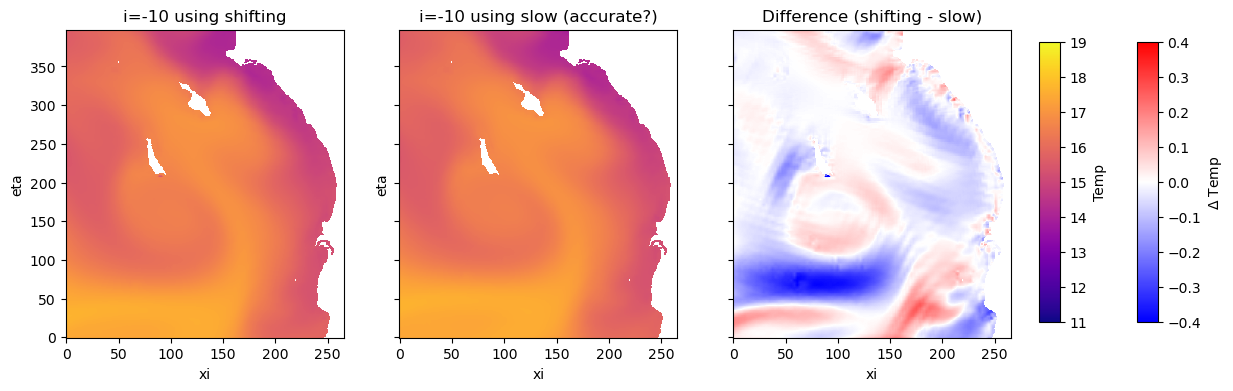

In [98]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3,sharey=True,figsize=(14,4))
#ds.vbar_north[22:42,0:140].transpose()
ax1.pcolor(norm.xi_rho,norm.eta_rho,norm.temp[-1,-10,:,:], vmin=11, vmax =19,cmap='plasma')
#ax1.plot([22,41],[238, 238], 'k--')
#ax1.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax1.set_ylabel('eta')
ax1.set_xlabel('xi')
ax1.set_title('i=-10 using shifting')

#plt.colorbar()
im = ax2.pcolor(slow.xi_rho,slow.eta_rho,slow.temp[-1,-10,:,:],vmin=11, vmax =19,cmap='plasma')
#ax2.plot([22,41],[238, 238], 'k--')
#ax2.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax2.set_ylabel('eta')
ax2.set_xlabel('xi')
ax2.set_title('i=-10 using slow (accurate?)')


im2 = ax3.pcolor(slow.xi_rho,slow.eta_rho,norm.temp[-1,-10,:,:]-slow.temp[-1,-10,:,:],vmin=-.4, vmax=.4,cmap='bwr')
#ax3.plot([22,41],[238, 238], 'k--')
#ax3.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax2.set_ylabel('eta')
ax3.set_xlabel('xi')
ax3.set_title('Difference (shifting - slow)')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.015, 0.7])
cbar_ax2 = fig.add_axes([0.89, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cba2 = fig.colorbar(im2, cax=cbar_ax2)
cba2.ax.set_ylabel('$\Delta$ Temp')
cbar.ax.set_ylabel('Temp')

/tmp/ipykernel_1814555/2518596042.py:32: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = fig.colorbar(im, cax=cbar_ax)
/tmp/ipykernel_1814555/2518596042.py:33: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cba2 = fig.colorbar(im2, cax=cbar_ax2)


Text(0, 0.5, 'Temp')

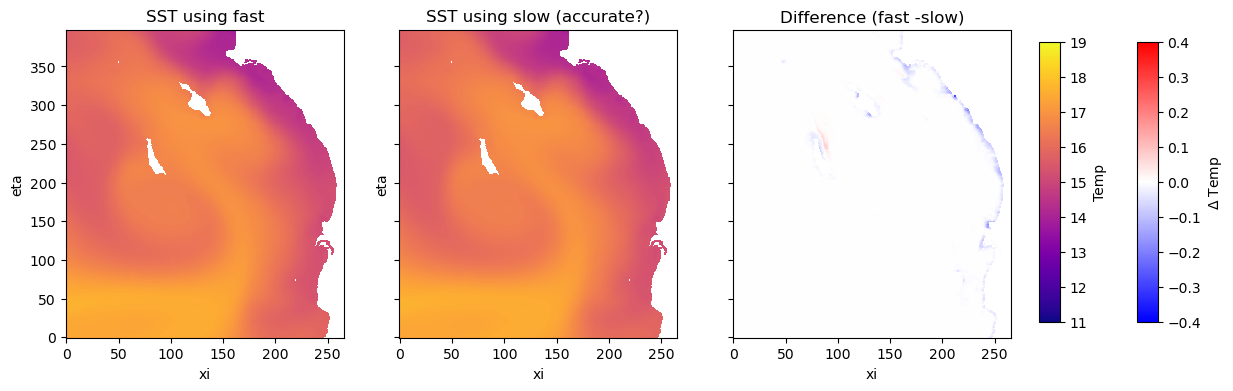

In [97]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3,sharey=True,figsize=(14,4))
#ds.vbar_north[22:42,0:140].transpose()
ax1.pcolor(fast.xi_rho,fast.eta_rho,fast.temp[-1,-10,:,:], vmin=11, vmax =19,cmap='plasma')
#ax1.plot([22,41],[238, 238], 'k--')
#ax1.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax1.set_ylabel('eta')
ax1.set_xlabel('xi')
ax1.set_title('SST using fast')

#plt.colorbar()
im = ax2.pcolor(slow.xi_rho,slow.eta_rho,slow.temp[-1,-10,:,:],vmin=11, vmax =19,cmap='plasma')
#ax2.plot([22,41],[238, 238], 'k--')
#ax2.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax2.set_ylabel('eta')
ax2.set_xlabel('xi')
ax2.set_title('SST using slow (accurate?)')


im2 = ax3.pcolor(slow.xi_rho,slow.eta_rho,fast.temp[-1,-10,:,:]-slow.temp[-1,-10,:,:],vmin=-.4, vmax=.4,cmap='bwr')
#ax3.plot([22,41],[238, 238], 'k--')
#ax3.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax2.set_ylabel('eta')
ax3.set_xlabel('xi')
ax3.set_title('Difference (fast -slow)')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.015, 0.7])
cbar_ax2 = fig.add_axes([0.89, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cba2 = fig.colorbar(im2, cax=cbar_ax2)
cba2.ax.set_ylabel('$\Delta$ Temp')
cbar.ax.set_ylabel('Temp')

In [4]:
ds_1 = xr.open_dataset('/scratch/bob/Hycom/h2017.10.01.09.nc')
print(ds_1)


<xarray.Dataset>
Dimensions:     (depth: 40, lat: 100, lon: 101, time: 1)
Coordinates:
  * depth       (depth) float64 0.0 2.0 4.0 6.0 ... 2.5e+03 3e+03 4e+03 5e+03
  * lat         (lat) float64 28.48 28.56 28.64 28.72 ... 36.16 36.24 36.32 36.4
  * lon         (lon) float64 -123.8 -123.7 -123.6 ... -115.9 -115.8 -115.8
  * time        (time) datetime64[ns] 2017-10-01T09:00:00
Data variables:
    salinity    (time, depth, lat, lon) float32 ...
    surf_el     (time, lat, lon) float32 ...
    water_temp  (time, depth, lat, lon) float32 ...
    water_u     (time, depth, lat, lon) float32 ...
    water_v     (time, depth, lat, lon) float32 ...
Attributes:
    classification_level:      UNCLASSIFIED
    distribution_statement:    Approved for public release. Distribution unli...
    downgrade_date:            not applicable
    classification_authority:  not applicable
    institution:               Naval Oceanographic Office
    source:                    HYCOM archive file
    history:  

In [2]:
ds_2 = xr.open_dataset('/scratch/bob/Hycom/ocean_bry_LV1_L1.nc')
print(ds_2)

<xarray.Dataset>
Dimensions:     (zeta_time: 62, v2d_time: 62, salt_time: 62, temp_time: 62,
                 v3d_time: 62, xi_rho: 253, eta_rho: 390, xi_u: 252,
                 eta_u: 390, xi_v: 253, eta_v: 389, s_rho: 40)
Coordinates:
  * zeta_time   (zeta_time) datetime64[ns] 2017-09-29 2017-09-30 ... 2017-12-01
  * v2d_time    (v2d_time) datetime64[ns] 2017-09-29 2017-09-30 ... 2017-12-01
  * salt_time   (salt_time) datetime64[ns] 2017-09-29 2017-09-30 ... 2017-12-01
  * temp_time   (temp_time) datetime64[ns] 2017-09-29 2017-09-30 ... 2017-12-01
  * v3d_time    (v3d_time) datetime64[ns] 2017-09-29 2017-09-30 ... 2017-12-01
Dimensions without coordinates: xi_rho, eta_rho, xi_u, eta_u, xi_v, eta_v, s_rho
Data variables: (12/28)
    zeta_north  (zeta_time, xi_rho) float64 ...
    zeta_south  (zeta_time, xi_rho) float64 ...
    zeta_east   (zeta_time, eta_rho) float64 ...
    zeta_west   (zeta_time, eta_rho) float64 ...
    ubar_north  (v2d_time, xi_u) float64 ...
    ubar_south  (v2d

NameError: name 'ds_1' is not defined

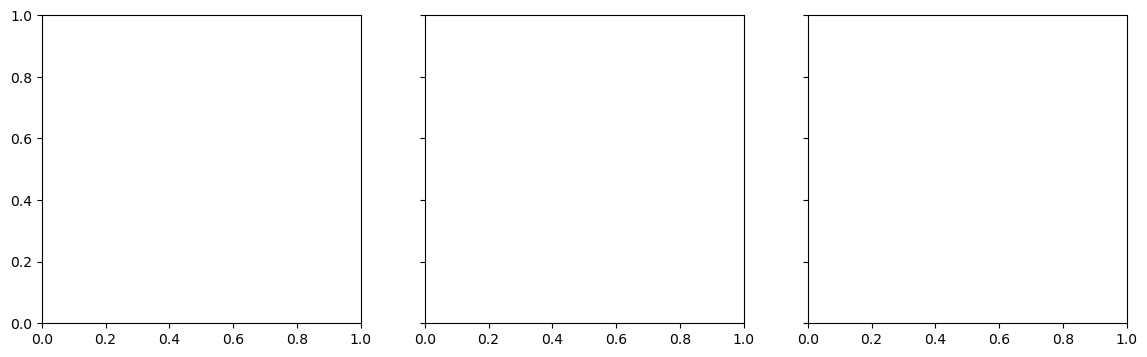

In [3]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3,sharey=True,figsize=(14,4))
#ds.vbar_north[22:42,0:140].transpose()
ax1.pcolor(ds_2.water_salt[-1,0,:,:], vmin=11, vmax =19,cmap='plasma')
#ax1.plot([22,41],[238, 238], 'k--')
#ax1.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax1.set_ylabel('eta')
ax1.set_xlabel('xi')
ax1.set_title('SST using fast')

#plt.colorbar()
im = ax2.pcolor(ds_2.water_temp[-1,0,:,:],vmin=11, vmax =19,cmap='plasma')
#ax2.plot([22,41],[238, 238], 'k--')
#ax2.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax2.set_ylabel('eta')
ax2.set_xlabel('xi')
ax2.set_title('SST using slow (accurate?)')


im2 = ax3.pcolor(ds_2.water_temp[-1,0,:,:].values,vmin=-.4, vmax=.4,cmap='bwr')
#ax3.plot([22,41],[238, 238], 'k--')
#ax3.plot([22,41],[238.849, 238.849], 'k')
#plt.plot(ds_hy.vbar_north[:,:].mean('xi_v'))
ax2.set_ylabel('eta')
ax3.set_xlabel('xi')
ax3.set_title('Difference (fast -slow)')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.015, 0.7])
cbar_ax2 = fig.add_axes([0.89, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cba2 = fig.colorbar(im2, cax=cbar_ax2)
cba2.ax.set_ylabel('$\Delta$ Temp')
cbar.ax.set_ylabel('Temp')